<a href="https://colab.research.google.com/github/elizmunoz-bui/Bone-fracture-detection-cv/blob/main/Insect-classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerias

In [ ]:
import os
from glob import glob
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report
)

# Cargar base de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
Ruta = "/content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento"

Mounted at /content/drive


# Distincion de clases y creacion de etiquetas

In [ ]:
# Clases
clases = [
    "Abejas",
    "Cucarrones",
    "Hormigas",
    "Avispas",
    "Chinches",
    "Palito",
    "Mantis"
]

# Listas finales
paths = []
labels = []
groups = []

# contador global de grupos
group_counter = 0

for clase in clases:

    ruta_clase = os.path.join(Ruta, clase)

    # leer imágenes
    imagenes = (
    glob(os.path.join(ruta_clase, "*.jpg")) +
    glob(os.path.join(ruta_clase, "*.JPG")) +
    glob(os.path.join(ruta_clase, "*.jpeg")) +
    glob(os.path.join(ruta_clase, "*.JPEG")) +
    glob(os.path.join(ruta_clase, "*.png")) +
    glob(os.path.join(ruta_clase, "*.PNG"))
)

    imagenes = sorted(imagenes)

    print(f"\nClase: {clase}")
    print(f"Cantidad imágenes: {len(imagenes)}")

    # cada imagen tendrá su propio grupo
    for i, img_path in enumerate(imagenes):

        grupo = group_counter + i

        paths.append(img_path)
        labels.append(clase)
        groups.append(grupo)

    # actualizar contador
    group_counter += len(imagenes)


# Crear DataFrame
df = pd.DataFrame({
    "path": paths,
    "label": labels,
    "group": groups
})


Clase: Abejas
Cantidad imágenes: 83

Clase: Cucarrones
Cantidad imágenes: 73

Clase: Hormigas
Cantidad imágenes: 70

Clase: Avispas
Cantidad imágenes: 72

Clase: Chinches
Cantidad imágenes: 72

Clase: Palito
Cantidad imágenes: 73

Clase: Mantis
Cantidad imágenes: 68


# Separacion de conjuntos

In [ ]:
# Divsion Train / Val / Test

from sklearn.model_selection import GroupShuffleSplit

# 1. Train (50%) y Val/Test (50%)

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=42
)

train_idx, temp_idx = next(
    gss.split(
        df["path"],
        df["label"],
        df["group"]
    )
)

train_df = df.iloc[train_idx].reset_index(drop=True)
temp_df = df.iloc[temp_idx].reset_index(drop=True)

# 2. Val (25%) y Test (25%)

gss2 = GroupShuffleSplit(
    n_splits=1,
    test_size=0.5,
    random_state=42
)

val_idx, test_idx = next(
    gss2.split(
        temp_df["path"],
        temp_df["label"],
        temp_df["group"]
    )
)

val_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df = temp_df.iloc[test_idx].reset_index(drop=True)

# Mostrar resultados
print("TRAIN:")
print(train_df["label"].value_counts())

print("\nVALIDATION:")
print(val_df["label"].value_counts())

print("\nTEST:")
print(test_df["label"].value_counts())

TRAIN:
label
Avispas       40
Palito        40
Hormigas      38
Chinches      38
Cucarrones    36
Abejas        33
Mantis        30
Name: count, dtype: int64

VALIDATION:
label
Abejas        24
Palito        20
Mantis        20
Cucarrones    18
Chinches      16
Hormigas      15
Avispas       15
Name: count, dtype: int64

TEST:
label
Abejas        26
Cucarrones    19
Chinches      18
Mantis        18
Hormigas      17
Avispas       17
Palito        13
Name: count, dtype: int64


# Preprocesamiento para EfficientNet

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# TRAIN, con augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    brightness_range=[0.8, 1.2],
    horizontal_flip=True
)

# VAL y TEST, sin augmentation
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generadores
train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

val_data = test_datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_data = test_datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 255 validated image filenames belonging to 7 classes.
Found 128 validated image filenames belonging to 7 classes.
Found 128 validated image filenames belonging to 7 classes.


 # Modelo 1 EfficientNetB0

In [ ]:
# Modelo EfficientNetB0
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# congelar capas
for layer in base_model.layers[:-20]:
    layer.trainable = False

# cabeza personalizada
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.2)(x)

output = Dense(7, activation='softmax')(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Compilar modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

In [ ]:
# Entrenamiento inicial
history = model.fit(
    train_data,

    validation_data=val_data,

    epochs=25,

    callbacks=[early_stop, reduce_lr]
)

Epoch 1/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 352s 20s/step - accuracy: 0.2745 - loss: 1.8663 - val_accuracy: 0.4297 - val_loss: 1.6454 - learning_rate: 1.0000e-04
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 449ms/step - accuracy: 0.6627 - loss: 1.4005 - val_accuracy: 0.6719 - val_loss: 1.2306 - learning_rate: 1.0000e-04
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 502ms/step - accuracy: 0.8000 - loss: 1.0880 - val_accuracy: 0.7812 - val_loss: 0.8615 - learning_rate: 1.0000e-04
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 495ms/step - accuracy: 0.9098 - loss: 0.7566 - val_accuracy: 0.8750 - val_loss: 0.5789 - learning_rate: 1.0000e-04
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 469ms/step - accuracy: 0.9333 - loss: 0.5193 - val_accuracy: 0.8750 - val_loss: 0.4375 - learning_rate: 1.0000e-04
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 521ms/step - accuracy: 0.9608 - loss: 0.3984 - val_accuracy: 0.8906 - val_loss: 0.3697 - learning_rate: 1.0000e-04
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 441ms/step - accuracy: 

In [ ]:
# Fine Tuning
base_model.trainable = True

for layer in base_model.layers[:-10]:
    layer.trainable = False

In [ ]:
# Recompilar
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

In [ ]:
# Entrenamiento Fine Tuning

history_finetune = model.fit(
    train_data,

    validation_data=val_data,

    epochs=15,

    callbacks=[early_stop, reduce_lr]
)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 1.0000 - loss: 0.0304 - val_accuracy: 0.9375 - val_loss: 0.1749 - learning_rate: 1.0000e-05
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 425ms/step - accuracy: 1.0000 - loss: 0.0369 - val_accuracy: 0.9297 - val_loss: 0.1753 - learning_rate: 1.0000e-05
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 540ms/step - accuracy: 0.9961 - loss: 0.0365 - val_accuracy: 0.9297 - val_loss: 0.1759 - learning_rate: 1.0000e-05
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 437ms/step - accuracy: 0.9922 - loss: 0.0442 - val_accuracy: 0.9297 - val_loss: 0.1761 - learning_rate: 1.0000e-05
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 532ms/step - accuracy: 1.0000 - loss: 0.0233 - val_accuracy: 0.9297 - val_loss: 0.1761 - learning_rate: 1.0000e-05
Epoch 6/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 428ms/step - accuracy: 1.0000 - loss: 0.0256 - val_accuracy: 0.9297 - val_loss: 0.1756 - learning_rate: 1.0000e-05


8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step
              precision    recall  f1-score   support

      Abejas       0.96      0.92      0.94        24
     Avispas       0.86      0.80      0.83        15
    Chinches       0.94      1.00      0.97        16
  Cucarrones       1.00      1.00      1.00        18
    Hormigas       0.87      0.87      0.87        15
      Mantis       0.95      1.00      0.98        20
      Palito       0.95      0.95      0.95        20

    accuracy                           0.94       128
   macro avg       0.93      0.93      0.93       128
weighted avg       0.94      0.94      0.94       128

Accuracy : 0.9375
Precision: 0.9369
Recall   : 0.9375
F1-score : 0.9368


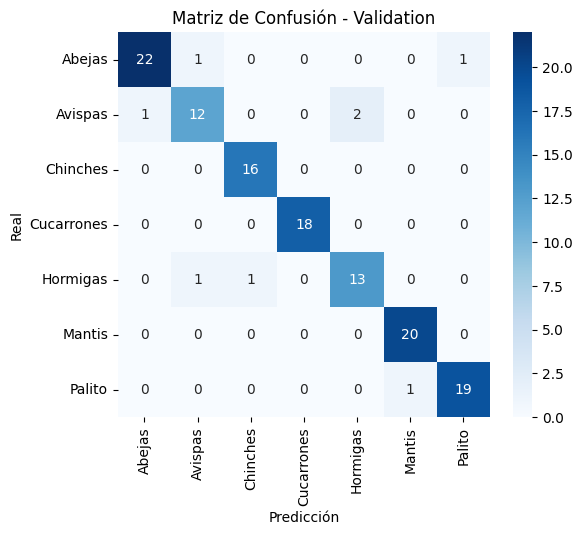

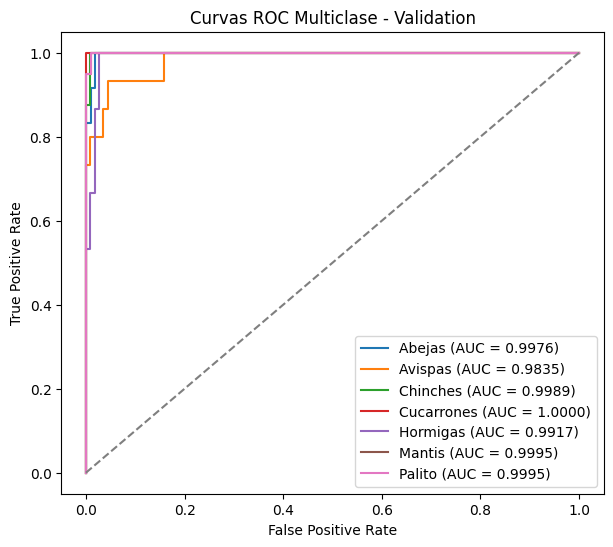

In [ ]:
# Metricas Validation
# predicciones
y_prob = model.predict(val_data)

y_pred = np.argmax(y_prob, axis=1)

y_true = val_data.classes

# métricas
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

# reporte
print(classification_report(
    y_true,
    y_pred,
    target_names=list(val_data.class_indices.keys())
))

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

# matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(val_data.class_indices.keys()),
    yticklabels=list(val_data.class_indices.keys())
)

plt.title("Matriz de Confusión - Validation")

plt.xlabel("Predicción")

plt.ylabel("Real")

plt.show()

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# binarizar etiquetas
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(val_data.class_indices))
)

n_classes = y_true_bin.shape[1]

plt.figure(figsize=(7,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{list(val_data.class_indices.keys())[i]} (AUC = {roc_auc:.4f})"
    )

# línea diagonal
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curvas ROC Multiclase - Validation")

plt.legend()

plt.show()

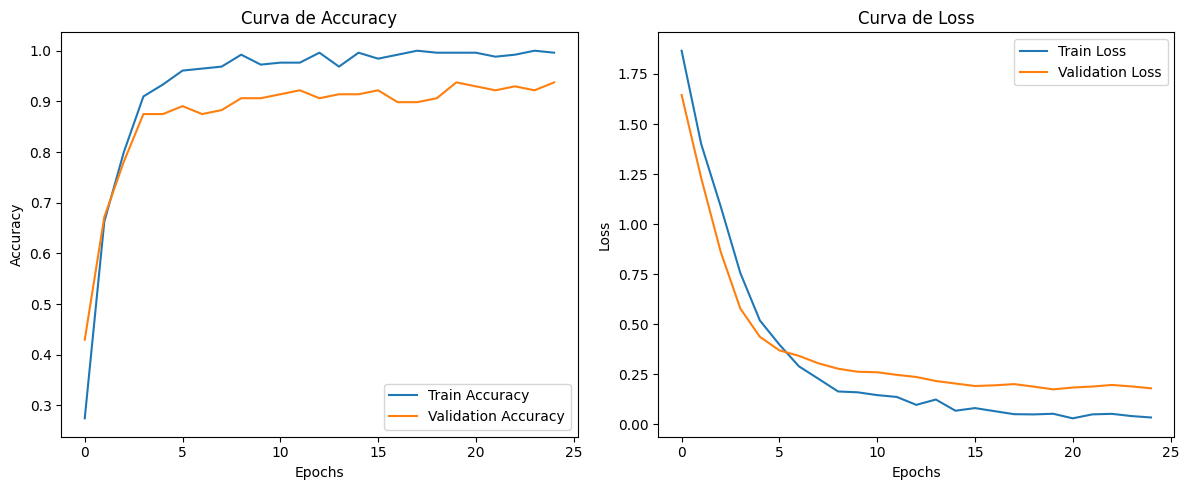

In [ ]:
# Curvas de Accuracy y Loss
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.title('Curva de Accuracy')

plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.title('Curva de Loss')

plt.legend()

plt.tight_layout()

plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 364ms/step
              precision    recall  f1-score   support

      Abejas       1.00      0.85      0.92        26
     Avispas       0.89      0.94      0.91        17
    Chinches       1.00      1.00      1.00        18
  Cucarrones       1.00      1.00      1.00        19
    Hormigas       0.85      1.00      0.92        17
      Mantis       1.00      1.00      1.00        18
      Palito       1.00      1.00      1.00        13

    accuracy                           0.96       128
   macro avg       0.96      0.97      0.96       128
weighted avg       0.97      0.96      0.96       128

Accuracy : 0.9609
Precision: 0.9653
Recall   : 0.9609
F1-score : 0.9609


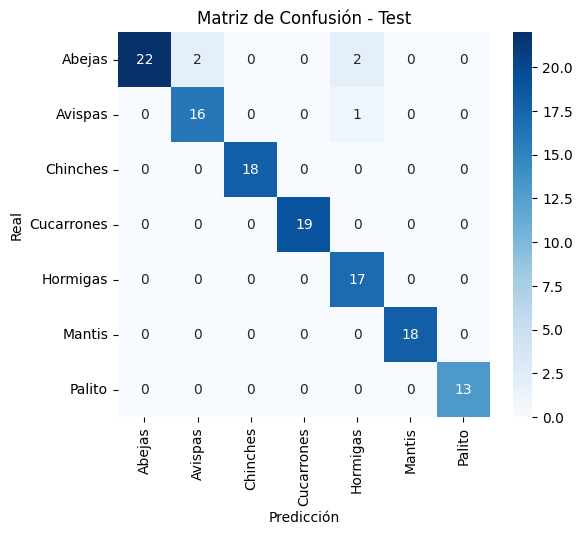

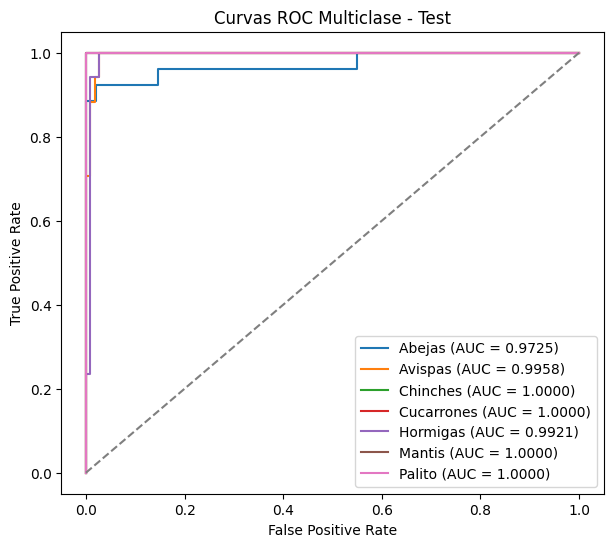

In [ ]:
# Metricas Test
# predicciones
y_prob_test = model.predict(test_data)

y_pred_test = np.argmax(y_prob_test, axis=1)

y_true_test = test_data.classes

# métricas
accuracy_test = accuracy_score(y_true_test, y_pred_test)

precision_test = precision_score(
    y_true_test,
    y_pred_test,
    average='weighted'
)

recall_test = recall_score(
    y_true_test,
    y_pred_test,
    average='weighted'
)

f1_test = f1_score(
    y_true_test,
    y_pred_test,
    average='weighted'
)

# reporte
print(classification_report(
    y_true_test,
    y_pred_test,
    target_names=list(test_data.class_indices.keys())
))

print(f"Accuracy : {accuracy_test:.4f}")
print(f"Precision: {precision_test:.4f}")
print(f"Recall   : {recall_test:.4f}")
print(f"F1-score : {f1_test:.4f}")

# matriz de confusión
cm_test = confusion_matrix(y_true_test, y_pred_test)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_data.class_indices.keys()),
    yticklabels=list(test_data.class_indices.keys())
)

plt.title("Matriz de Confusión - Test")

plt.xlabel("Predicción")

plt.ylabel("Real")

plt.show()

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# binarizar etiquetas
y_true_test_bin = label_binarize(
    y_true_test,
    classes=np.arange(len(test_data.class_indices))
)

n_classes = y_true_test_bin.shape[1]

plt.figure(figsize=(7,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_true_test_bin[:, i],
        y_prob_test[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{list(test_data.class_indices.keys())[i]} (AUC = {roc_auc:.4f})"
    )

# línea diagonal
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("Curvas ROC Multiclase - Test")

plt.legend()

plt.show()

In [ ]:
model.save(f"{Ruta}/modelo_EfficientNetInsectos.keras")

NameError: name 'model' is not defined

# MODELO 2 MobileNetV2

In [ ]:
#PREPROCESAMIENTO PARA EfficientNetBMobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
base_model = tf.keras.applications.MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [ ]:
#  Preprocesamiento nativo de MobileNetV2

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Dimensiones estándar para MobileNetV2
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,       # Subimos de 15 a 25 para mayor variedad de ángulos
    zoom_range=0.2,           # Incrementamos a 0.2 para simular distancias
    width_shift_range=0.1,    # Ajuste de traslación horizontal
    height_shift_range=0.1,   # Ajuste de traslación vertical
    brightness_range=[0.7, 1.3], # Mayor tolerancia a cambios de luz en las fotos
    horizontal_flip=True,
    vertical_flip=True        #  giro vertical (útil para insectos en cualquier posición)
)

#  VAL y TEST
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("Cargando conjunto de ENTRENAMIENTO")
train_data = train_datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True  # mezclar las 7 categorías en cada lote
)

print("\nCargando conjunto de VALIDACIÓN")
val_data = test_datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\n🏁 Cargando conjunto de PRUEBA...")
test_data = test_datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nGeneradores de MobileNetV2 listos para las clases")

Cargando conjunto de ENTRENAMIENTO
Found 255 validated image filenames belonging to 7 classes.

Cargando conjunto de VALIDACIÓN
Found 128 validated image filenames belonging to 7 classes.

🏁 Cargando conjunto de PRUEBA...
Found 128 validated image filenames belonging to 7 classes.

Generadores de MobileNetV2 listos para las clases


Variable 'train_data' encontrada 
Forma del lote de imágenes: (16, 224, 224, 3)
Forma del lote de etiquetas: (16, 7)


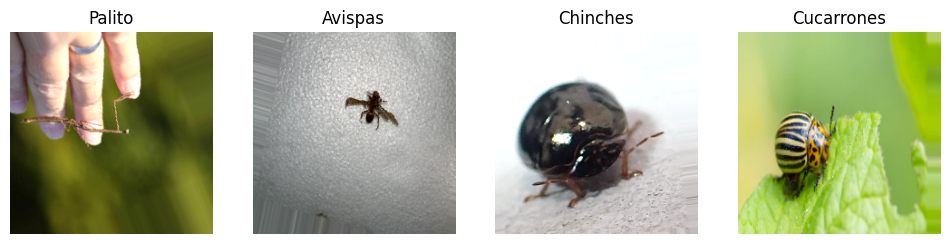

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if 'train_data' in locals() or 'train_data' in globals():
    print("Variable 'train_data' encontrada ")

    # Extraemos un lote (batch) de entrenamiento
    x_batch, y_batch = next(train_data)

    # dimensiones del lote
    print(f"Forma del lote de imágenes: {x_batch.shape}")
    print(f"Forma del lote de etiquetas: {y_batch.shape}")

    # Mapeo invertido de clases para saber el nombre
    class_labels = list(train_data.class_indices.keys())

    # Graficar las primeras 4 imágenes del lote
    plt.figure(figsize=(12, 4))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        img = x_batch[i]

        # Ajuste visual por si preprocess_input alteró los rangos de color
        if img.min() < 0:
            img = (img - img.min()) / (img.max() - img.min())
        elif img.max() > 1.0:
            img = img / 255.0

        plt.imshow(img)
        plt.title(class_labels[np.argmax(y_batch[i])])
        plt.axis("off")
    plt.show()
else:
    print(" Error: 'train_data' ")

 Variable 'train_data' encontrada .
Forma del lote de imágenes: (16, 224, 224, 3) -> (Imágenes, Alto, Ancho, Canales)
Forma del lote de etiquetas: (16, 7) -> (Imágenes, 7 Clases)


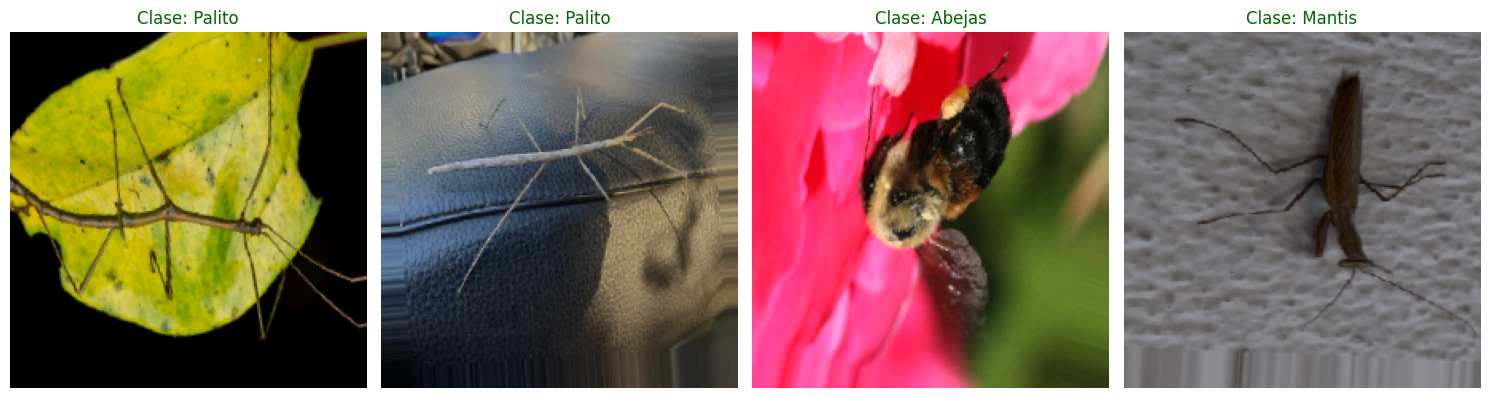

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

if 'train_data' in locals() or 'train_data' in globals():
    print(" Variable 'train_data' encontrada .")

    # Extraemos un solo lote (batch) de entrenmine
    x_batch, y_batch = next(train_data)

    # Mostrar las dimensiones del lote
    print(f"Forma del lote de imágenes: {x_batch.shape} -> (Imágenes, Alto, Ancho, Canales)")
    print(f"Forma del lote de etiquetas: {y_batch.shape} -> (Imágenes, {y_batch.shape[1]} Clases)")

    class_labels = list(train_data.class_indices.keys())

    #para mostrar las primeras 4 imágenes del lote
    plt.figure(figsize=(15, 5))
    for i in range(4):
        plt.subplot(1, 4, i+1)
        img = x_batch[i].copy()


        # Revierte el rango [-1, 1] de vuelta al rango visual estándar [0, 1]
        img = (img + 1.0) / 2.0
        img = np.clip(img, 0.0, 1.0) # Asegura que ningún píxel se salga de los límites

        # Graficar la imagen
        plt.imshow(img)


        clase_detectada = class_labels[np.argmax(y_batch[i])]
        plt.title(f"Clase: {clase_detectada}", fontsize=12, color="darkgreen")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("No se encontró la variable 'train_data'")

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# 1. Cargamos el modelo base
base_model_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_mobile.trainable = False

# 2. Cabeza personalizada
x = base_model_mobile.output
x = GlobalAveragePooling2D()(x)

# Capa intermedia regulada
x = Dense(32, activation='relu', kernel_regularizer=l2(0.02))(x)
x = Dropout(0.2)(x)


output = Dense(7, activation='softmax')(x)

# 3. Construccion del modelo
model_mobile = Model(inputs=base_model_mobile.input, outputs=output)

model_mobile.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo MobileNetV2  compilado ")

Modelo MobileNetV2  compilado 


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# 10 épocas
EPOCHS = 10

print("Configurando los callbacks de control")
callbacks_fijos = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),


    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),

    ModelCheckpoint(filepath='mejor_mobilenet.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]


print("niciando el entrenamiento de MobileNetV2 con las 7 clases de insectos")


history_mobile = model_mobile.fit(
    train_data,                # Datos de entrenamiento
    validation_data=val_data,  # Datos de validación
    epochs=EPOCHS,
    callbacks=callbacks_fijos
)

Configurando los callbacks de control
niciando el entrenamiento de MobileNetV2 con las 7 clases de insectos
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - accuracy: 0.1693 - loss: 3.3948
Epoch 1: val_accuracy improved from None to 0.39062, saving model to mejor_mobilenet.keras

Epoch 1: finished saving model to mejor_mobilenet.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.2196 - loss: 3.2043 - val_accuracy: 0.3906 - val_loss: 2.8342 - learning_rate: 5.0000e-04
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 339ms/step - accuracy: 0.4292 - loss: 2.6918
Epoch 2: val_accuracy improved from 0.39062 to 0.71875, saving model to mejor_mobilenet.keras

Epoch 2: finished saving model to mejor_mobilenet.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 490ms/step - accuracy: 0.4941 - loss: 2.6054 - val_accuracy: 0.7188 - val_loss: 2.3049 - learning_rate: 5.0000e-04
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.6568 - loss: 2.3080
Epoch 3: val_accuracy improved from 0.71875 to 

In [ ]:

from tensorflow.keras.optimizers import Adam
import tensorflow as tf

print(" Descongelando las últimas capas de MobileNetV2 para Fine-Tuning")

base_model_mobile.trainable = True


# Bloqueo de las capas de BatchNormalization para evitar que colapse la precisión.
for layer in base_model_mobile.layers[:-10]:
    layer.trainable = False

for layer in base_model_mobile.layers[-10:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


#tasa de aprendizaje ultra baja  1e-5

model_mobile.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Modelo MobileNetV2  preparado para Fine-Tuning.")

# 4. Entrenamiento de Ajuste Fino (5 épocas)
history_finetune = model_mobile.fit(
    train_data,
    validation_data=val_data,
    epochs=5,                  # 5 épocas
    callbacks=callbacks_fijos
)

 Descongelando las últimas capas de MobileNetV2 para Fine-Tuning
Modelo MobileNetV2  preparado para Fine-Tuning.
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9326 - loss: 1.1749
Epoch 1: val_accuracy improved from 0.88281 to 0.89062, saving model to mejor_mobilenet.keras

Epoch 1: finished saving model to mejor_mobilenet.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step - accuracy: 0.9176 - loss: 1.1909 - val_accuracy: 0.8906 - val_loss: 1.2383 - learning_rate: 1.0000e-05
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9115 - loss: 1.1811
Epoch 2: val_accuracy improved from 0.89062 to 0.89844, saving model to mejor_mobilenet.keras

Epoch 2: finished saving model to mejor_mobilenet.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 576ms/step - accuracy: 0.9216 - loss: 1.1636 - val_accuracy: 0.8984 - val_loss: 1.2277 - learning_rate: 1.0000e-05
Epoch 3/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.8999 - loss: 1.1758
Epoch 3: val_accuracy did not improve from

Generación de predicciones del modelo MobileNetV2 sobre el conjunto de VALIDACIÓN
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 314ms/step

REPORTE DE CLASIFICACIÓN GENERAL
              precision    recall  f1-score   support

      Abejas       0.95      0.88      0.91        24
     Avispas       0.87      0.87      0.87        15
    Chinches       0.94      0.94      0.94        16
  Cucarrones       0.90      1.00      0.95        18
    Hormigas       0.80      0.80      0.80        15
      Mantis       0.90      0.90      0.90        20
      Palito       0.90      0.90      0.90        20

    accuracy                           0.90       128
   macro avg       0.89      0.90      0.89       128
weighted avg       0.90      0.90      0.90       128

🔹 Accuracy (Exactitud Global) : 0.8984
🔹 Precision (Precisión ): 0.8993
🔹 Recall (Sensibilidad ): 0.8984
🔹 F1-score (Balance )   : 0.8982


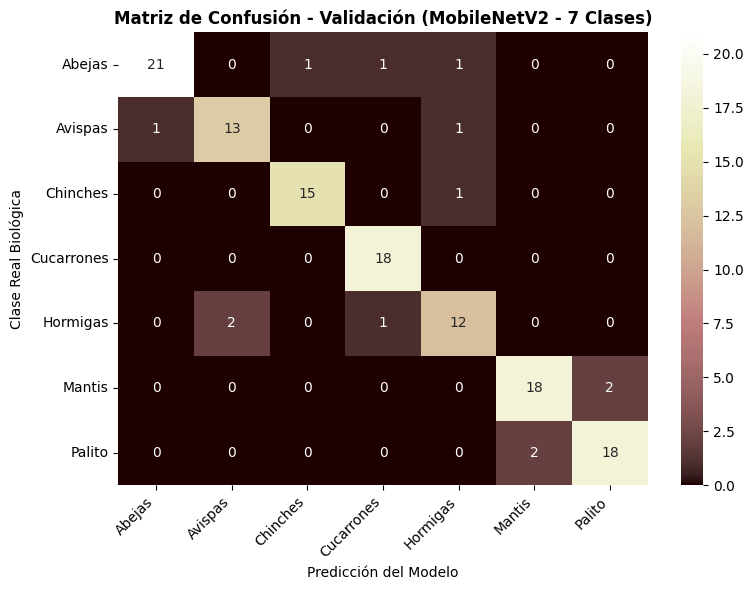

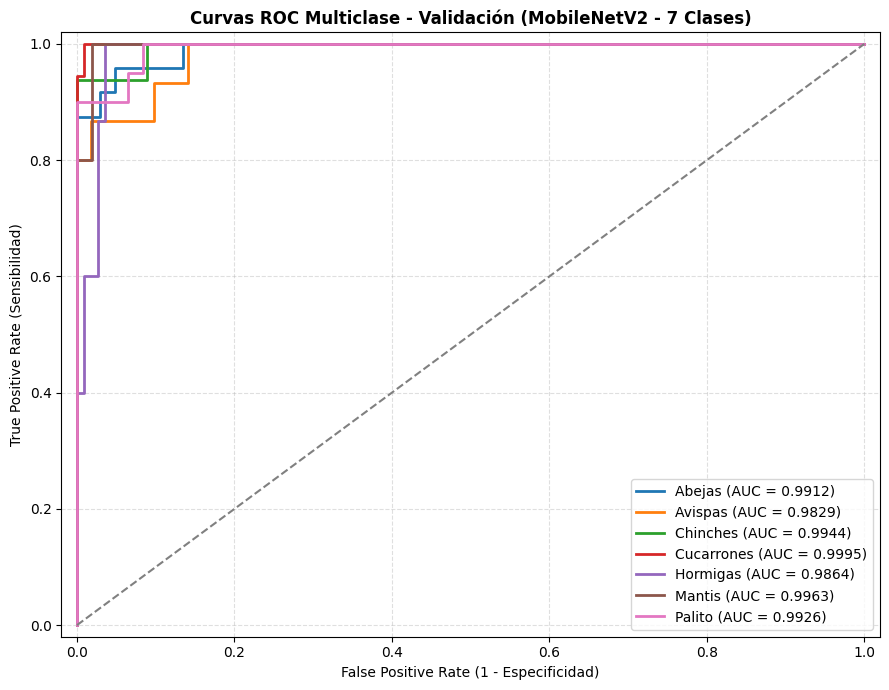

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print("Generación de predicciones del modelo MobileNetV2 sobre el conjunto de VALIDACIÓN")
#  probabilidades y las clases reales
y_prob = model_mobile.predict(val_data)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_data.classes
nombres_clases = list(val_data.class_indices.keys())
total_clases = len(nombres_clases)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("\nREPORTE DE CLASIFICACIÓN GENERAL")
print(classification_report(y_true, y_pred, target_names=nombres_clases))

print(f"🔹 Accuracy (Exactitud Global) : {accuracy:.4f}")
print(f"🔹 Precision (Precisión ): {precision:.4f}")
print(f"🔹 Recall (Sensibilidad ): {recall:.4f}")
print(f"🔹 F1-score (Balance )   : {f1:.4f}")


# 3. MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='pink',
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
)
plt.title("Matriz de Confusión - Validación (MobileNetV2 - 7 Clases)", fontsize=12, fontweight='bold')
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real Biológica")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 4. CURVAS ROC MULTICLASE
y_true_bin = label_binarize(y_true, classes=list(range(total_clases)))

plt.figure(figsize=(9, 7))
for i in range(total_clases):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{nombres_clases[i]} (AUC = {roc_auc:.4f})"
    )

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Especificidad)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curvas ROC Multiclase - Validación (MobileNetV2 - 7 Clases)", fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

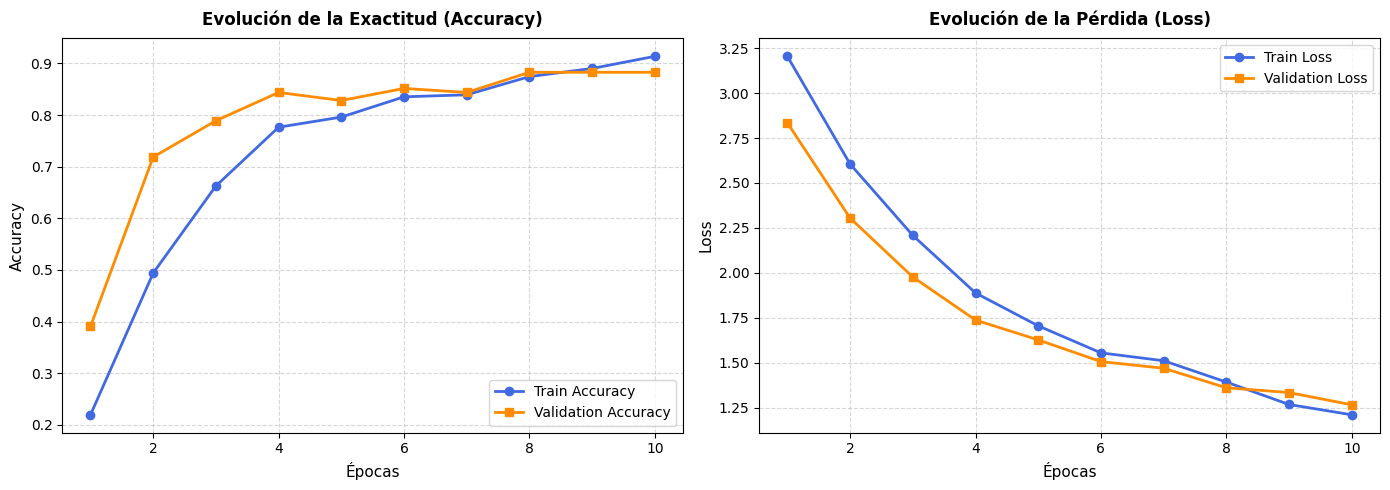

In [ ]:
import matplotlib.pyplot as plt

#historial de las 10 épocas base
acc = history_mobile.history['accuracy']
val_acc = history_mobile.history['val_accuracy']
loss = history_mobile.history['loss']
val_loss = history_mobile.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))

# GRÁFICA 1: ACCURACY
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Train Accuracy', marker='o', color='royalblue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='s', color='darkorange', linewidth=2)
plt.xlabel('Épocas', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Evolución de la Exactitud (Accuracy)', fontsize=12, fontweight='bold', pad=10)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

# GRÁFICA 2: LOSS
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Train Loss', marker='o', color='royalblue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='s', color='darkorange', linewidth=2)
plt.xlabel('Épocas', fontsize=11)
plt.ylabel('Loss', fontsize=11)
plt.title('Evolución de la Pérdida (Loss)', fontsize=12, fontweight='bold', pad=10)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Evaluando predicciones finales del modelo MobileNetV2 sobre el conjunto de TEST
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step

================ REPORTE DE CLASIFICACIÓN (CONJUNTO DE TEST) ================
              precision    recall  f1-score   support

      Abejas       1.00      0.85      0.92        26
     Avispas       0.85      1.00      0.92        17
    Chinches       1.00      1.00      1.00        18
  Cucarrones       0.95      1.00      0.97        19
    Hormigas       0.89      0.94      0.91        17
      Mantis       1.00      0.89      0.94        18
      Palito       0.93      1.00      0.96        13

    accuracy                           0.95       128
   macro avg       0.95      0.95      0.95       128
weighted avg       0.95      0.95      0.95       128

🔹 Accuracy (Exactitud de Test) : 0.9453
🔹 Precision (Precisión de Test): 0.9506
🔹 Recall (Sensibilidad de Test): 0.9453
🔹 F1-score (Balance de Test)   : 0.9451



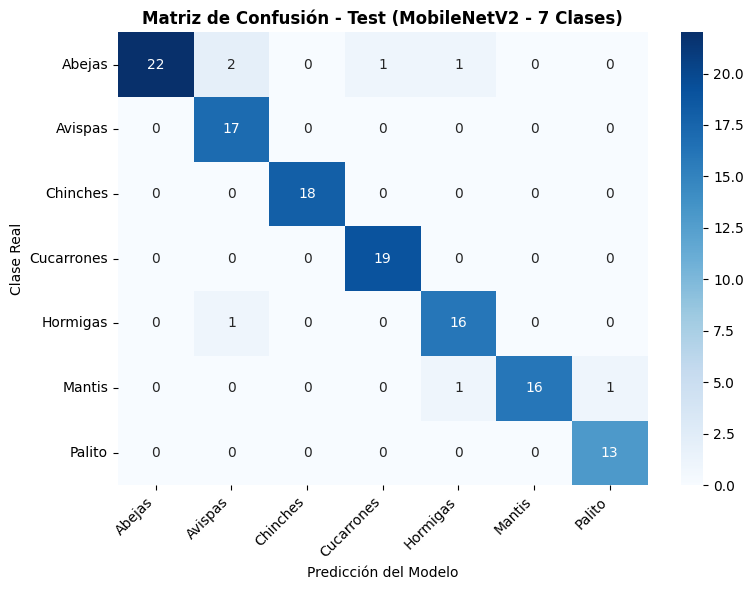

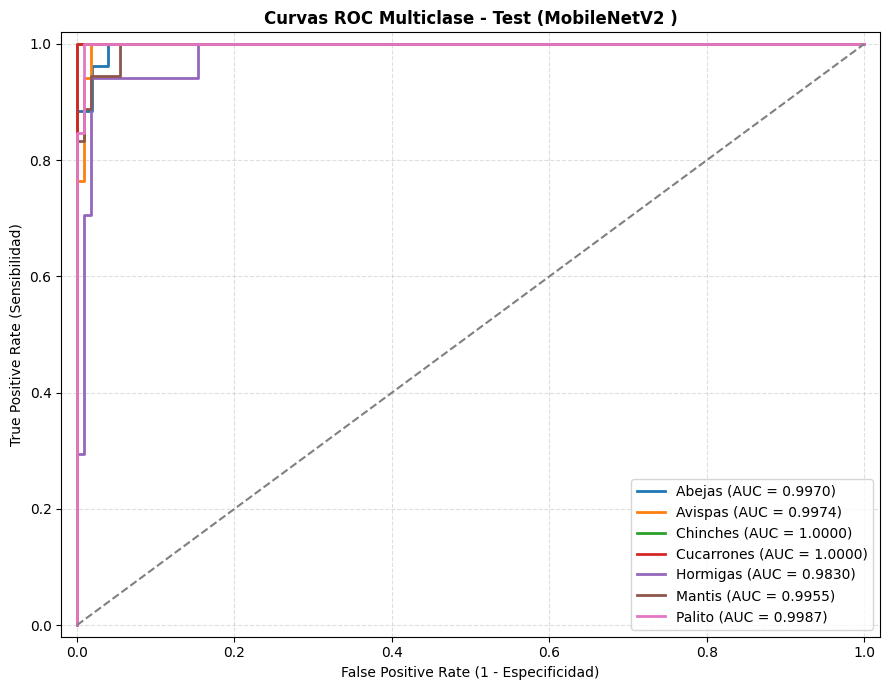

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

print("Evaluando predicciones finales del modelo MobileNetV2 sobre el conjunto de TEST")
y_prob_test = model_mobile.predict(test_data)
y_pred_test = np.argmax(y_prob_test, axis=1)
y_true_test = test_data.classes
nombres_clases = list(test_data.class_indices.keys())
total_clases = len(nombres_clases)

# Cálculo de métricas globales ponderadas para Test
accuracy_test = accuracy_score(y_true_test, y_pred_test)
precision_test = precision_score(y_true_test, y_pred_test, average='weighted')
recall_test = recall_score(y_true_test, y_pred_test, average='weighted')
f1_test = f1_score(y_true_test, y_pred_test, average='weighted')

print("\n================ REPORTE DE CLASIFICACIÓN (CONJUNTO DE TEST) ================")
print(classification_report(y_true_test, y_pred_test, target_names=nombres_clases))

print(f"🔹 Accuracy (Exactitud de Test) : {accuracy_test:.4f}")
print(f"🔹 Precision (Precisión de Test): {precision_test:.4f}")
print(f"🔹 Recall (Sensibilidad de Test): {recall_test:.4f}")
print(f"🔹 F1-score (Balance de Test)   : {f1_test:.4f}")
print("================================================================================\n")

# MATRIZ DE CONFUSIÓN - TEST
cm_test = confusion_matrix(y_true_test, y_pred_test)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=nombres_clases,
    yticklabels=nombres_clases
)
plt.title("Matriz de Confusión - Test (MobileNetV2 - 7 Clases)", fontsize=12, fontweight='bold')
plt.xlabel("Predicción del Modelo")
plt.ylabel("Clase Real")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# CURVAS ROC MULTICLASE - TEST
y_true_test_bin = label_binarize(y_true_test, classes=list(range(total_clases)))

plt.figure(figsize=(9, 7))
for i in range(total_clases):
    fpr, tpr, _ = roc_curve(y_true_test_bin[:, i], y_prob_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{nombres_clases[i]} (AUC = {roc_auc:.4f})"
    )

# Línea diagonal
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5)
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Especificidad)")
plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curvas ROC Multiclase - Test (MobileNetV2 )", fontsize=12, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# MODELO 3 Densenet121



In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as preprocess_densenet

# --- 1. Generadores Específicos para DenseNet121 ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# Entrenamiento con Data Augmentation robusto (incluyendo vertical_flip para insectos)
train_datagen_dense = ImageDataGenerator(
    preprocessing_function=preprocess_densenet,
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.7, 1.3],
    horizontal_flip=True,
    vertical_flip=True
)

test_datagen_dense = ImageDataGenerator(preprocessing_function=preprocess_densenet)

train_data_dense = train_datagen_dense.flow_from_dataframe(
    train_df, x_col="path", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="categorical", shuffle=True
)
val_data_dense = test_datagen_dense.flow_from_dataframe(
    val_df, x_col="path", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)
test_data_dense = test_datagen_dense.flow_from_dataframe(
    test_df, x_col="path", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="categorical", shuffle=False
)

Found 255 validated image filenames belonging to 7 classes.
Found 128 validated image filenames belonging to 7 classes.
Found 128 validated image filenames belonging to 7 classes.


In [ ]:
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
# --- 2. Construcción del Modelo ---
base_model_dense = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_dense.trainable = False

x = base_model_dense.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x) # Capa intermedia densa para regular patrones
x = Dropout(0.3)(x)
output_dense = Dense(7, activation='softmax')(x)

model_dense = Model(inputs=base_model_dense.input, outputs=output_dense)

model_dense.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks fijos actualizados para guardar el mejor DenseNet en tu Drive
callbacks_dense = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(filepath=f"{Ruta}/mejor_densenet.keras", monitor='val_accuracy', save_best_only=True, verbose=1)
]

In [ ]:
# --- 3. Entrenamiento Inicial (Capas Congeladas) ---
print("Entrenando cabeza personalizada de DenseNet121...")
history_dense = model_dense.fit(
    train_data_dense, validation_data=val_data_dense,
    epochs=10, callbacks=callbacks_dense
)

Entrenando cabeza personalizada de DenseNet121...
Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.2065 - loss: 2.0895
Epoch 1: val_accuracy improved from None to 0.57031, saving model to /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/mejor_densenet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/mejor_densenet.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 139s 8s/step - accuracy: 0.2706 - loss: 1.8960 - val_accuracy: 0.5703 - val_loss: 1.2901 - learning_rate: 5.0000e-04
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5413 - loss: 1.1699
Epoch 2: val_accuracy improved from 0.57031 to 0.78125, saving model to /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/mejor_densenet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/mejor_densenet.keras
16/16 ━━━

In [ ]:
# --- 4. Fine-Tuning ---
print("\nDescongelando últimas capas de DenseNet121 para Fine-Tuning...")
base_model_dense.trainable = True

# Congelar hasta las últimas 15 capas y asegurar que BatchNormalization permanezca congelada
for layer in base_model_dense.layers[:-15]:
    layer.trainable = False
for layer in base_model_dense.layers[-15:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model_dense.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune_dense = model_dense.fit(
    train_data_dense, validation_data=val_data_dense,
    epochs=5, callbacks=callbacks_dense
)


Descongelando últimas capas de DenseNet121 para Fine-Tuning...
Epoch 1/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9580 - loss: 0.2163
Epoch 1: val_accuracy improved from 0.92188 to 0.92969, saving model to /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/mejor_densenet.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/mejor_densenet.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 104s 5s/step - accuracy: 0.9294 - loss: 0.2429 - val_accuracy: 0.9297 - val_loss: 0.2951 - learning_rate: 1.0000e-05
Epoch 2/5
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9334 - loss: 0.2139
Epoch 2: val_accuracy improved from 0.92969 to 0.93750, saving model to /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/mejor_densenet.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/mejor_densenet.

In [ ]:
# --- 5. Guardado del Historial de Entrenamiento en el Drive ---
# Convertimos las historias de las dos fases a DataFrames de Pandas
df_hist_base = pd.DataFrame(history_dense.history)
df_hist_ft = pd.DataFrame(history_finetune_dense.history)

# Concatenamos cronológicamente para tener un registro único y limpio
df_historia_total = pd.concat([df_hist_base, df_hist_ft], ignore_index=True)
df_historia_total.to_csv(f"{Ruta}/historial_entrenamiento_densenet.csv", index=False)
print(f"\n✅ Historial de entrenamiento guardado exitosamente en: {Ruta}/historial_entrenamiento_densenet.csv")


✅ Historial de entrenamiento guardado exitosamente en: /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/historial_entrenamiento_densenet.csv



Evaluando sobre el conjunto de VALIDACIÓN...
8/8 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step
              precision    recall  f1-score   support

      Abejas       1.00      0.83      0.91        24
     Avispas       0.94      1.00      0.97        15
    Chinches       0.88      0.94      0.91        16
  Cucarrones       1.00      0.89      0.94        18
    Hormigas       0.79      1.00      0.88        15
      Mantis       1.00      1.00      1.00        20
      Palito       1.00      1.00      1.00        20

    accuracy                           0.95       128
   macro avg       0.94      0.95      0.94       128
weighted avg       0.95      0.95      0.95       128



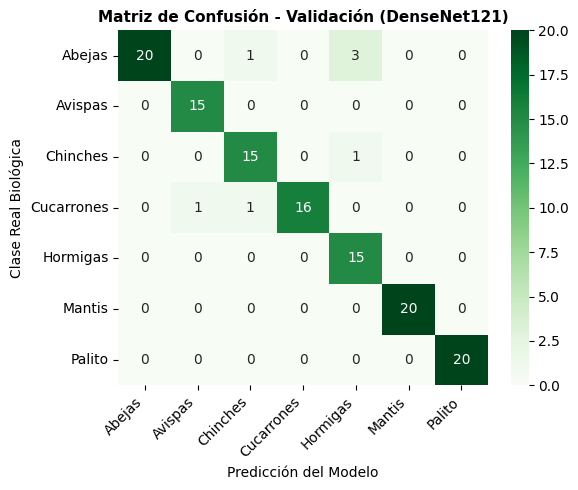

In [ ]:
# --- 6. Evaluación en el Conjunto de VALIDACIÓN ---
print("\nEvaluando sobre el conjunto de VALIDACIÓN...")
y_prob = model_dense.predict(val_data_dense)
y_pred = np.argmax(y_prob, axis=1)
y_true = val_data_dense.classes
nombres_clases = list(val_data_dense.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=nombres_clases))

# Matriz de Confusión - Validación (Compacta)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Greens',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title("Matriz de Confusión - Validación (DenseNet121)", fontsize=11, fontweight='bold')
plt.xlabel("Predicción del Modelo"); plt.ylabel("Clase Real Biológica")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()


================ EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST ================
8/8 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step
              precision    recall  f1-score   support

      Abejas       1.00      0.73      0.84        26
     Avispas       0.84      0.94      0.89        17
    Chinches       0.78      1.00      0.88        18
  Cucarrones       1.00      0.89      0.94        19
    Hormigas       0.74      0.82      0.78        17
      Mantis       1.00      1.00      1.00        18
      Palito       1.00      1.00      1.00        13

    accuracy                           0.90       128
   macro avg       0.91      0.91      0.90       128
weighted avg       0.91      0.90      0.90       128



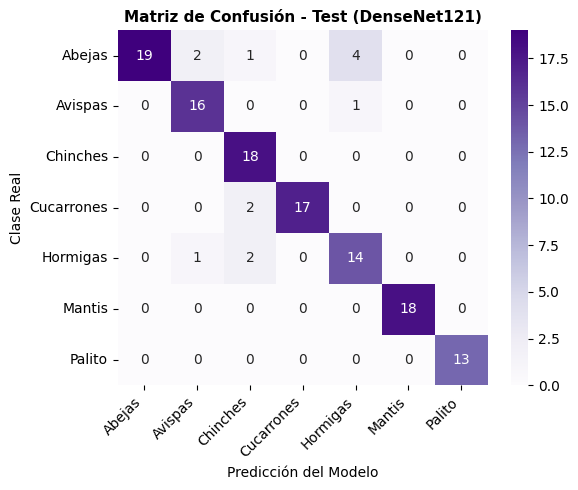

In [ ]:
# --- 7. Evaluación Final en el Conjunto de TEST ---
print("\n================ EVALUACIÓN FINAL SOBRE EL CONJUNTO DE TEST ================")
y_prob_test = model_dense.predict(test_data_dense)
y_pred_test = np.argmax(y_prob_test, axis=1)
y_true_test = test_data_dense.classes

print(classification_report(y_true_test, y_pred_test, target_names=nombres_clases))

# Matriz de Confusión - Test (Compacta)
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true_test, y_pred_test), annot=True, fmt='d', cmap='Purples',
            xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title("Matriz de Confusión - Test (DenseNet121)", fontsize=11, fontweight='bold')
plt.xlabel("Predicción del Modelo"); plt.ylabel("Clase Real")
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

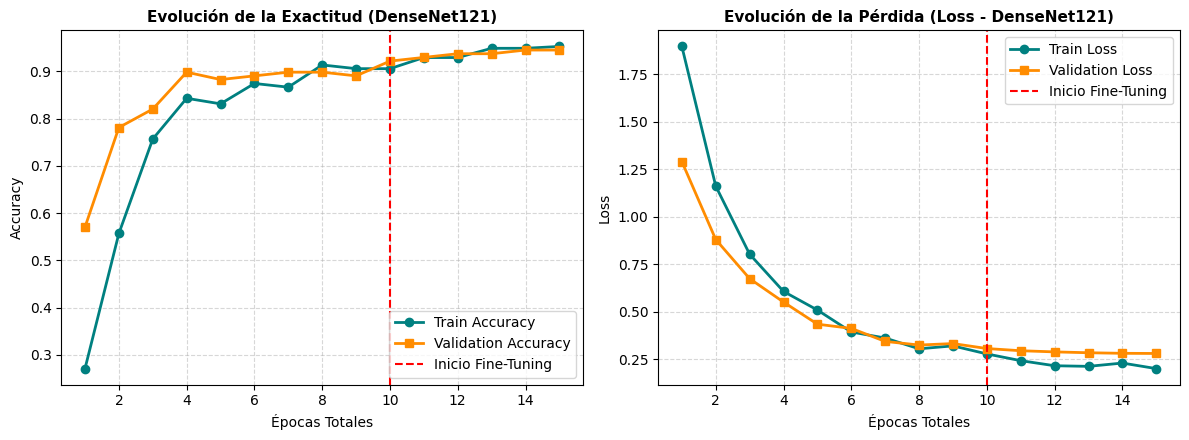

In [ ]:
# --- 8. Gráficas de Rendimiento Continuas
acc_total = df_historia_total['accuracy']
val_acc_total = df_historia_total['val_accuracy']
loss_total = df_historia_total['loss']
val_loss_total = df_historia_total['val_loss']
epochs_range = range(1, len(acc_total) + 1)

plt.figure(figsize=(12, 4.5))
# Gráfica Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc_total, label='Train Accuracy', marker='o', color='teal', linewidth=2)
plt.plot(epochs_range, val_acc_total, label='Validation Accuracy', marker='s', color='darkorange', linewidth=2)
plt.axvline(x=len(df_hist_base), color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.xlabel('Épocas Totales'); plt.ylabel('Accuracy')
plt.title('Evolución de la Exactitud (DenseNet121)', fontsize=11, fontweight='bold')
plt.legend(loc='lower right'); plt.grid(True, linestyle='--', alpha=0.5)

# Gráfica Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss_total, label='Train Loss', marker='o', color='teal', linewidth=2)
plt.plot(epochs_range, val_loss_total, label='Validation Loss', marker='s', color='darkorange', linewidth=2)
plt.axvline(x=len(df_hist_base), color='red', linestyle='--', label='Inicio Fine-Tuning')
plt.xlabel('Épocas Totales'); plt.ylabel('Loss')
plt.title('Evolución de la Pérdida (Loss - DenseNet121)', fontsize=11, fontweight='bold')
plt.legend(loc='upper right'); plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(); plt.show()


📊 TABLA COMPARATIVA DE RENDIMIENTO (DenseNet121)
              Métrica  Validación  Prueba (Test)
 Accuracy (Exactitud)    0.945312       0.898438
Precision (Ponderada)    0.953299       0.913508
Recall (Sensibilidad)    0.945312       0.898438
   F1-Score (Balance)    0.945752       0.898736
✅ Tabla de métricas exportada a: /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/tabla_metricas_densenet.csv


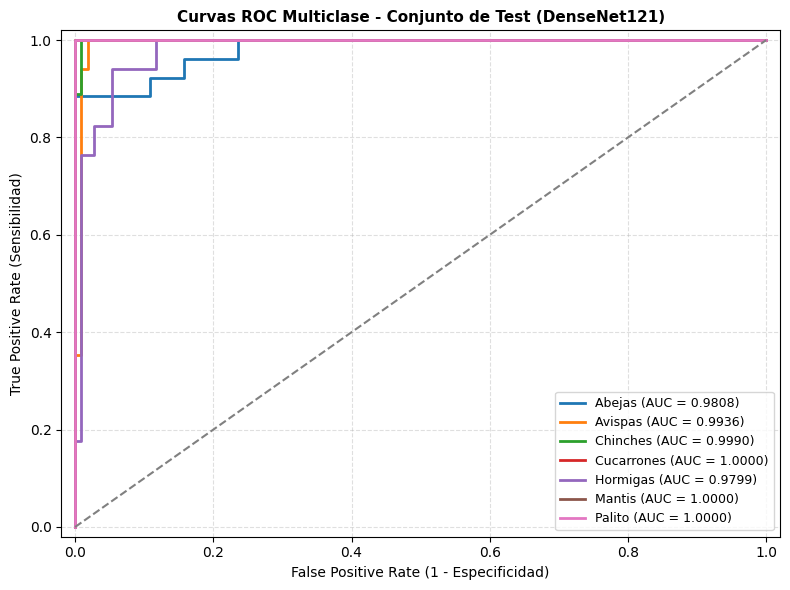


💾 ¡Modelo final guardado exitosamente en tu Drive!: /content/drive/MyDrive/Colab Notebooks/Electiva Deep Learning/TercerProyectoAumento/modelo_DenseNet121_Insectos.keras


In [ ]:
# ====================================================================
# TABLA DE MÉTRICAS, CURVAS ROC Y GUARDADO DEFINITIVO
# ====================================================================
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Construcción de la Tabla de Métricas Organizada
metricas_resumen = {
    "Métrica": ["Accuracy (Exactitud)", "Precision (Ponderada)", "Recall (Sensibilidad)", "F1-Score (Balance)"],
    "Validación": [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, average='weighted'),
        recall_score(y_true, y_pred, average='weighted'),
        f1_score(y_true, y_pred, average='weighted')
    ],
    "Prueba (Test)": [
        accuracy_score(y_true_test, y_pred_test),
        precision_score(y_true_test, y_pred_test, average='weighted'),
        recall_score(y_true_test, y_pred_test, average='weighted'),
        f1_score(y_true_test, y_pred_test, average='weighted')
    ]
}

# Crear DataFrame para visualizarlo como tabla limpia
df_metricas = pd.DataFrame(metricas_resumen)
print("\n📊 TABLA COMPARATIVA DE RENDIMIENTO (DenseNet121)")
print(df_metricas.to_string(index=False))

# Guardar la tabla en formato CSV dentro del Drive para el informe
df_metricas.to_csv(f"{Ruta}/tabla_metricas_densenet.csv", index=False)
print(f"✅ Tabla de métricas exportada a: {Ruta}/tabla_metricas_densenet.csv")


# 2. Curvas ROC Multiclase - Conjunto de Test (Estilo Compacto)
y_true_test_bin = label_binarize(y_true_test, classes=list(range(len(nombres_clases))))

plt.figure(figsize=(8, 6))
for i in range(len(nombres_clases)):
    fpr, tpr, _ = roc_curve(y_true_test_bin[:, i], y_prob_test[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f"{nombres_clases[i]} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1.5)
plt.xlim([-0.02, 1.02]); plt.ylim([-0.02, 1.02])
plt.xlabel("False Positive Rate (1 - Especificidad)"); plt.ylabel("True Positive Rate (Sensibilidad)")
plt.title("Curvas ROC Multiclase - Conjunto de Test (DenseNet121)", fontsize=11, fontweight='bold')
plt.legend(loc="lower right", fontsize=9); plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()


# 3. Guardado Explícito y Definitivo del Modelo Final en el Drive
model_dense.save(f"{Ruta}/modelo_DenseNet121_Insectos.keras")
print(f"\n💾 ¡Modelo final guardado exitosamente en tu Drive!: {Ruta}/modelo_DenseNet121_Insectos.keras")

# INTERFAZ

In [ ]:
# 1. Aseguramos la instalación más limpia de gradio
!pip install -q gradio

import gradio as gr
import tensorflow as tf
import numpy as np
import warnings
import logging
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.efficientnet import preprocess_input
from PIL import Image

warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger("uvicorn.error").setLevel(logging.CRITICAL)
tf.get_logger().setLevel('ERROR')

print("⏳ Cargando modelo entrenado de insectos")
try:
    modelo_despliegue = tf.keras.models.load_model('/content/drive/MyDrive/TercerProyectoAumento/modelo_EfficientNetInsectos.keras')
    print(" ¡Modelo cargado exitosamente desde Drive!")
except Exception as e:
    print(f"Error al cargar: {e}")

# ALINEACIÓN
nombres_clases = [
    "Abeja 🐝",                 # Índice 0
    "Avispa 🦟",                # Índice 1
    "Chinche 🪳",               # Índice 2
    "Cucarrón / Escarabajo 🪲", # Índice 3
    "Hormiga 🐜",               # Índice 4
    "Mantis Religiosa 🦎",       # Índice 5
    "Insecto Palito 🪵"          # Índice 6
]

# 🧬 Base de datos ecológica
datos_curiosos = {
    "Abeja 🐝": {
        "grupo": "Himenópteros (Hymenoptera)",
        "familia": "Apidae",
        "habitats": "Usualmente éstos insectos aparecen en campos de flores, zonas agrícolas y áreas silvestres en nuestro territorio caucano",
        "curiosidad": "Sabías que: Son los polinizadores más importantes del planeta. Se comunican mediante un 'baile' en forma de ocho para indicar la ubicación de flores ricas en néctar.",
        "eco_msg": "🌿 Sin abejas, la seguridad alimentaria colapsaría. Evita el uso de pesticidas químicos en los cultivos de la región."
    },
    "Avispa 🦟": {
        "grupo": "Himenópteros (Hymenoptera)",
        "familia": "Vespidae",
        "habitats": "Suele estar encontrarse en zonas boscosas, áreas abiertas y entornos rurales del Cauca.",
        "curiosidad": "Ten cuidado ya que a diferencia de las abejas, las avispas pueden picar múltiples veces. Son depredadoras fundamentales que controlan plagas biológicas como orugas y moscas.",
        "eco_msg": "🐝  Pero, aunque tienen mala fama, son controladoras ecológicas vitales. No destruyas sus nidos a menos que sea estrictamente necesario."
    },
    "Chinche 🪳": {
        "grupo": "Hemípteros (Hemiptera)",
        "familia": "Pentatomidae / Reduviidae",
        "habitats": "Zonas de cultivo, arbustos y jardines locales.",
        "curiosidad": "Poseen un aparato bucal en forma de aguja succionadora. Algunas especies segregan sustancias de olor fuerte como mecanismo de defensa.",
        "eco_msg": "🌱 Muchas especies de chinches actúan como cazadoras de otros insectos que dañan la agricultura, manteniendo el equilibrio biológico."
    },
    "Cucarrón / Escarabajo 🪲": {
        "grupo": "Coleópteros (Coleoptera)",
        "familia": "Scarabaeidae / Carabidae",
        "habitats": "Bosques andinos, hojarasca y troncos en descomposición en el territorio caucano.",
        "curiosidad": "Es el grupo animal más diverso de la Tierra. Sus alas delanteras evolucionaron en una armadura rígida protectora llamada 'élitros'.",
        "eco_msg": "🍂 Los escarabajos reciclan la materia orgánica y fertilizan los suelos. ¡Evita pisarlos! Son los limpiadores de la naturaleza."
    },
    "Hormiga 🐜": {
        "grupo": "Himenópteros (Hymenoptera)",
        "familia": "Formicidae",
        "habitats": "Suelos y vegetación en diversos pisos térmicos del departamento.",
        "curiosidad": "Pueden cargar hasta 50 veces su propio peso y operan en complejas estructuras sociales que funcionan como un único superorganismo.",
        "eco_msg": "🐜 Las hormigas airean la tierra permitiendo que las raíces respiren. Respeta sus senderos y sus nidos."
    },
    "Mantis Religiosa 🦎": {
        "grupo": "Mantodeos (Mantodea)",
        "familia": "Mantidae",
        "habitats": "Pastizales, huertos y áreas verdes del departamento.",
        "curiosidad": "Cazadoras letales con visión tridimensional. Tienen patas delanteras raptoras con espinas y su cabeza puede girar hasta 180 grados.",
        "eco_msg": "🦗  Las mantis son guardianas naturales de los cultivos al devorar plagas. ¡Respétalas y admira su elegancia!"
    },
    "Insecto Palito 🪵": {
        "grupo": "Fásmidos (Phasmatodea)",
        "familia": "Phasmatidae",
        "habitats": "Matorrales y follajes densos protegidos en el Cauca.",
        "curiosidad": "Son los maestros del mimetismo. Se quedan inmóviles por horas y se balancean suavemente simulando ser ramas movidas por el viento.",
        "eco_msg": "🌳  Dependen exclusivamente de la vegetación nativa. Proteger las reservas forestales del Cauca es resguardar su hogar invisible."
    }
}

def clasificar_insecto(imagen_entrada):
    if imagen_entrada is None:
        return {}, "Por favor, sube una imagen ."

    # Conversión a objeto PIL Image
    img_pil = Image.fromarray(imagen_entrada.astype('uint8'), 'RGB')

    # Preprocesamiento para EfficientNet (224x224)
    img = img_pil.resize((224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # Predicción
    predicciones = modelo_despliegue.predict(img_array)[0]

    # Identificación del ganador
    indice_ganador = np.argmax(predicciones)
    clase_ganadora = nombres_clases[indice_ganador]

    info = datos_curiosos[clase_ganadora]

    # Ficha Técnica Ecológica en formato Markdown para la pantalla
    reporte_html = f"""
    ### 🔬 Ficha Técnica: {clase_ganadora}

    * **Grupo Taxonómico:** {info['grupo']}
    * **Familia:** {info['familia']}
    * **Distribución / Hábitat:** {info['habitats']}

    📌 **Datos Curiosos:**
    {info['curiosidad']}

    ---
    {info['eco_msg']}
    """

    # Retorno de probabilidades ordenadas y el reporte de texto estructurado
    diccionario_probabilidades = {nombres_clases[i]: float(predicciones[i]) for i in range(len(nombres_clases))}
    return diccionario_probabilidades, reporte_html


# ====================================================================
# 🎨 INTERFAZ GRÁFICA PREMIUM (Universidad del Cauca)
# ====================================================================
with gr.Blocks(theme=gr.themes.Soft(primary_hue="green", secondary_hue="emerald")) as interfaz_premium:

    gr.Markdown(
        """
        # 🔬 Identificador Taxonómico de Insectos (Universidad del Cauca)
        ### *Conciencia Ambiental en el Cauca*
        Sube una fotografía para identificar el insecto. Al hacer clic en **Analizar Insecto**, el modelo calculará las probabilidades y generará la **Ficha Técnica Ecológica e Historial de Conservación** directamente en el panel inferior.
        """
    )

    gr.Markdown("---")

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📸 Entrada de Datos")
            imagen_input = gr.Image(type="numpy", label="Arrastra o toma una foto del insecto")
            btn_clasificar = gr.Button("🚀 Analizar Insecto", variant="primary")

        with gr.Column(scale=1):
            gr.Markdown("### 📊 Diagnóstico del Modelo")
            etiqueta_output = gr.Label(num_top_classes=7, label="Probabilidades de Coincidencia")

            gr.Markdown("---")
            gr.Markdown("### 🌿 Información Biológica y Ambiental")
            # 🚨 NUEVO ELEMENTO VISUAL: Cuadro de texto dinámico para mostrar el reporte ecológico
            reporte_output = gr.Markdown(value="*Esperando análisis de imagen...*", label="Reporte Ecológico")

    # Configuramos el botón para que actualice tanto las barras como el texto Markdown
    btn_clasificar.click(
        fn=clasificar_insecto,
        inputs=imagen_input,
        outputs=[etiqueta_output, reporte_output]
    )

    gr.Markdown(
        """
        ---
        *Desarrollado por estudiantes de la Universidad del Cauca. Proyecto con enfoque bio-educativo para el monitoreo territorial y el cuidado de los micro-ecosistemas del Cauca.*
        """
    )

# Lanzamos el servidor con el link público activo
interfaz_premium.launch(share=True, debug=True)

⏳ Cargando modelo entrenado de insectos
 ¡Modelo cargado exitosamente desde Drive!
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://854361e99661590440.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
